In [6]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn as nn
import torch.optim as optim

device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [9]:
spx = pd.read_csv("spx_options.csv", index_col=0)

spx['riskfreeRate'] = 0.0365
spx["tau"] = spx['timetoMaturity'] / 365
spx['midPrice'] = (spx['bid'] + spx['ask']) / 2
spx["logS_over_K"] = np.log(spx["spotPrice"] / spx["strike"])

spx.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,inTheMoney,contractSize,currency,ticker,spotPrice,timetoMaturity,riskfreeRate,tau,midPrice,logS_over_K
0,SPX260320C03400000,2026-03-04 19:37:33+00:00,3400.0,3482.48,3213.5,3234.9,0.00000,0.000000,40.0,72.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,3224.20,0.668160
1,SPX260320C03950000,2025-12-30 17:57:28+00:00,3950.0,2976.08,2995.3,3009.7,0.00000,0.000000,1700.0,1701.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,3002.50,0.518219
2,SPX260320C04000000,2026-03-13 15:23:52+00:00,4000.0,2674.60,2616.2,2630.7,-39.18994,-1.444104,1000.0,11653.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2623.45,0.505641
3,SPX260320C04050000,2026-03-09 20:00:39+00:00,4050.0,2754.40,2566.2,2580.8,0.00000,0.000000,20.0,1700.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,2573.50,0.493218
4,SPX260320C04950000,2025-04-07 09:13:42+00:00,4950.0,509.70,1000.0,1005.7,0.00000,0.000000,10.0,224.0,...,True,REGULAR,USD,^SPX,6632.189941,7,0.0365,0.019178,1002.85,0.292547


In [45]:
data = spx[["strike", "tau", "logS_over_K", "impliedVolatility", "midPrice"]].copy()

data.rename(columns={'strike': "K", "impliedVolatility": "sigma", "midPrice": "V"}, inplace=True)

data['V_scaled'] = data['V'] / data['K']

data = data[(data["sigma"] > 0.03) & (data["sigma"] < 1.0) & (data["logS_over_K"] > -0.5) & (data["logS_over_K"] < 0.5)]
print(f"Filtered dataset size: {len(data)}")
data.head()

Filtered dataset size: 859


,K,tau,logS_over_K,sigma,V,V_scaled
7,5200.0,0.019178,0.243276,0.643314,1425.45,0.274125
9,5450.0,0.019178,0.196319,0.593998,1176.35,0.215844
10,5500.0,0.019178,0.187187,0.737551,1128.30,0.205145
18,6000.0,0.019178,0.100176,0.475576,631.80,0.105300
20,6125.0,0.019178,0.079556,0.297920,508.35,0.082996


In [40]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(data, test_size=0.2, random_state=42, shuffle=True)

In [47]:
import torch
from torch.utils.data import Dataset, DataLoader

class OptionDataset(Dataset):
    def __init__(self, df):
        self.strike = torch.tensor(df["K"].values, dtype=torch.float32).view(-1, 1)
        self.tau = torch.tensor(df["tau"].values, dtype=torch.float32).view(-1, 1)
        self.sigma = torch.tensor(df["sigma"].values, dtype=torch.float32).view(-1, 1)
        self.price = torch.tensor(df["logS_over_K"].values, dtype=torch.float32).view(-1, 1)
        self.value = torch.tensor(df["V"].values, dtype=torch.float32).view(-1, 1)
        self.value_scaled = torch.tensor(df["V_scaled"].values, dtype=torch.float32).view(-1, 1)

    def __len__(self):
        return len(self.price)

    def __getitem__(self, idx):
        return {
            "tau": self.tau[idx],
            "sigma": self.sigma[idx],
            "logS_over_K": self.price[idx],
            "V_scaled": self.value_scaled[idx]
        }

train_dataset = OptionDataset(train_df)
val_dataset = OptionDataset(val_df)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

In [48]:
import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm


# =========================================================
# Device
# =========================================================
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


# =========================================================
# Normalizer utilities
# We normalize the 3 physical inputs:
#   x = log(S/K), tau, sigma
# but still differentiate wrt the physical variables.
# =========================================================
@torch.no_grad()
def fit_input_normalizer_from_loader(loader, device):
    feats = []

    for batch in loader:
        x = batch["logS_over_K"].to(device).view(-1, 1).float()
        tau = batch["tau"].to(device).view(-1, 1).float()
        sigma = batch["sigma"].to(device).view(-1, 1).float()

        feats.append(torch.cat([x, tau, sigma], dim=1))

    X = torch.cat(feats, dim=0)
    mean = X.mean(dim=0, keepdim=True)
    std = X.std(dim=0, unbiased=False, keepdim=True).clamp_min(1e-6)
    return mean, std


@torch.no_grad()
def infer_domain_from_loader(loader, device, x_pad=0.10, tau_pad=0.00, sigma_pad=0.00):
    xs, taus, sigmas = [], [], []

    for batch in loader:
        xs.append(batch["logS_over_K"].to(device).view(-1, 1).float())
        taus.append(batch["tau"].to(device).view(-1, 1).float())
        sigmas.append(batch["sigma"].to(device).view(-1, 1).float())

    x_all = torch.cat(xs, dim=0)
    tau_all = torch.cat(taus, dim=0)
    sigma_all = torch.cat(sigmas, dim=0)

    x_min = x_all.min().item()
    x_max = x_all.max().item()
    tau_min = max(0.0, tau_all.min().item())
    tau_max = tau_all.max().item()
    sigma_min = max(1e-4, sigma_all.min().item())
    sigma_max = sigma_all.max().item()

    # Slight padding for PDE collocation
    x_width = max(x_max - x_min, 1e-6)
    tau_width = max(tau_max - tau_min, 1e-6)
    sigma_width = max(sigma_max - sigma_min, 1e-6)

    domain = {
        "x_min": x_min - x_pad * x_width,
        "x_max": x_max + x_pad * x_width,
        "tau_min": max(0.0, tau_min - tau_pad * tau_width),
        "tau_max": tau_max + tau_pad * tau_width,
        "sigma_min": max(1e-4, sigma_min - sigma_pad * sigma_width),
        "sigma_max": sigma_max + sigma_pad * sigma_width,
    }
    return domain


def sample_uniform(n, low, high, device):
    return torch.rand(n, 1, device=device) * (high - low) + low


def sample_collocation_batch(n, domain, device, tau_floor=1e-6):
    x = sample_uniform(n, domain["x_min"], domain["x_max"], device)
    tau_low = max(domain["tau_min"], tau_floor)
    tau = sample_uniform(n, tau_low, domain["tau_max"], device)
    sigma = sample_uniform(n, domain["sigma_min"], domain["sigma_max"], device)
    return x, tau, sigma


def curriculum_domain(full_domain, epoch, curriculum_epochs=75, start_frac=0.35):
    """
    Widens the PDE sampling box over the first curriculum_epochs.
    This is a simple curriculum regularization scheme.
    """
    if curriculum_epochs <= 0:
        return full_domain

    alpha = min(1.0, epoch / float(curriculum_epochs))
    frac = start_frac + (1.0 - start_frac) * alpha

    x_min = min(0.0, full_domain["x_min"] * frac)
    x_max = max(0.0, full_domain["x_max"] * frac)

    tau_min = full_domain["tau_min"]
    tau_max = full_domain["tau_min"] + frac * (full_domain["tau_max"] - full_domain["tau_min"])
    tau_max = max(tau_max, tau_min + 1e-6)

    sigma_min = full_domain["sigma_min"]
    sigma_max = full_domain["sigma_min"] + frac * (full_domain["sigma_max"] - full_domain["sigma_min"])
    sigma_max = max(sigma_max, sigma_min + 1e-6)

    return {
        "x_min": x_min,
        "x_max": x_max,
        "tau_min": tau_min,
        "tau_max": tau_max,
        "sigma_min": sigma_min,
        "sigma_max": sigma_max,
    }


# =========================================================
# Black-Scholes scaled call in transformed variables
# u = C/K
# =========================================================
def norm_cdf(z):
    return 0.5 * (1.0 + torch.erf(z / math.sqrt(2.0)))


def bs_call_scaled_from_x(x, tau, r, sigma):
    """
    Returns u = C/K for a European call.
    x = log(S/K)
    """
    eps = 1e-8
    tau_pos = torch.clamp(tau, min=0.0)
    sigma = torch.clamp(sigma, min=1e-6)

    intrinsic = torch.clamp(torch.exp(x) - 1.0, min=0.0)

    sqrt_tau = torch.sqrt(tau_pos + eps)
    vol_sqrt_tau = sigma * sqrt_tau + eps

    d1 = (x + (r + 0.5 * sigma**2) * tau_pos) / vol_sqrt_tau
    d2 = d1 - sigma * sqrt_tau

    u_cont = torch.exp(x) * norm_cdf(d1) - torch.exp(-r * tau_pos) * norm_cdf(d2)

    return torch.where(tau_pos < 1e-6, intrinsic, u_cont)


# =========================================================
# Model
# Smooth activations only: tanh everywhere
# =========================================================
class ResidualBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.fc1 = nn.Linear(width, width)
        self.fc2 = nn.Linear(width, width)
        self.act = nn.Tanh()

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.act(self.fc2(h))
        return x + h

class PINN(nn.Module):
    def __init__(self, in_dim=3, hidden_dim=128, n_blocks=4):
        super().__init__()
        self.in_dim = in_dim

        self.input_layer = nn.Linear(in_dim, hidden_dim)
        self.blocks = nn.ModuleList([ResidualBlock(hidden_dim) for _ in range(n_blocks)])
        self.output_layer = nn.Linear(hidden_dim, 1)
        self.act = nn.Tanh()

        self.register_buffer("feature_mean", torch.zeros(1, in_dim))
        self.register_buffer("feature_std", torch.ones(1, in_dim))

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def set_normalizer(self, mean, std):
        self.feature_mean.copy_(mean.detach().clone().view(1, -1))
        self.feature_std.copy_(std.detach().clone().view(1, -1).clamp_min(1e-6))

    def _stack_and_normalize(self, x, tau, sigma):
        feats = torch.cat([x, tau, sigma], dim=1)
        return (feats - self.feature_mean) / self.feature_std

    def forward(self, x, tau=None, sigma=None):
        if tau is None and sigma is None:
            # x here is actually the full feature tensor [logS_over_K, tau, sigma]
            feats_raw = x
            feats = (feats_raw - self.feature_mean) / self.feature_std

            x_phys = feats_raw[:, 0:1]
            tau_phys = feats_raw[:, 1:2]
        else:
            x_phys = x
            tau_phys = tau
            feats = self._stack_and_normalize(x, tau, sigma)

        h = self.act(self.input_layer(feats))
        for block in self.blocks:
            h = block(h)

        raw = self.output_layer(h)

        intrinsic = torch.clamp(torch.expm1(x_phys), min=0.0)
        tau_pos = torch.clamp(tau_phys, min=0.0)
        time_value = tau_pos * F.softplus(raw)

        return intrinsic + time_value


# =========================================================
# Derivatives / PDE residual
# =========================================================
def gradients(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
        only_inputs=True,
    )[0]


def pde_residual(model, x, tau, sigma, r):
    """
    PDE in x = log(S/K), tau, sigma coordinates:

        u_tau - 0.5 sigma^2 u_xx - (r - 0.5 sigma^2) u_x + r u = 0
    """
    x = x.clone().detach().requires_grad_(True)
    tau = tau.clone().detach().requires_grad_(True)
    sigma = sigma.clone().detach()

    u = model(x, tau, sigma)

    u_tau = gradients(u, tau)
    u_x = gradients(u, x)
    u_xx = gradients(u_x, x)

    resid = (
        u_tau
        - 0.5 * sigma**2 * u_xx
        - (r - 0.5 * sigma**2) * u_x
        + r * u
    )
    return resid


# =========================================================
# Losses
# =========================================================
def data_loss(model, x, tau, sigma, v_scaled, weights=None):
    pred = model(x, tau, sigma)
    err2 = (pred - v_scaled) ** 2

    if weights is not None:
        weights = weights / weights.mean().clamp_min(1e-8)
        err2 = err2 * weights

    return err2.mean()


def terminal_loss(model, x, sigma):
    tau0 = torch.zeros_like(x)
    pred = model(x, tau0, sigma)
    target = torch.clamp(torch.exp(x) - 1.0, min=0.0)
    return torch.mean((pred - target) ** 2)


def boundary_loss(model, tau, sigma, r, x_min, x_max):
    # Left boundary: deep OTM call => u ~ 0
    x_left = torch.full_like(tau, float(x_min))
    u_left = model(x_left, tau, sigma)
    loss_left = torch.mean(u_left ** 2)

    # Right boundary: deep ITM call => u ~ e^x - e^{-r tau}
    x_right = torch.full_like(tau, float(x_max))
    u_right = model(x_right, tau, sigma)
    target_right = torch.exp(x_right) - torch.exp(-r * tau)
    loss_right = torch.mean((u_right - target_right) ** 2)

    return loss_left + loss_right


@torch.no_grad()
def predict_scaled(model, x, tau, sigma):
    return model(x, tau, sigma)


@torch.no_grad()
def predict_price(model, x, tau, sigma, K):
    u = model(x, tau, sigma)
    return u * K

In [51]:
def train_european_call_pinn(
    train_loader,
    val_loader,
    r,
    device,
    hidden_dim=128,
    n_blocks=4,
    lr=8e-4,
    weight_decay=1e-5,
    n_epochs=300,
    patience=60,
    lambda_data=8.0,
    lambda_pde=0.5,
    lambda_tc=4.0,
    lambda_bc=1.0,
    n_col=2048,
    n_tc=512,
    n_bc=512,
    pretrain_steps=500,
    pretrain_batch=2048,
    curriculum_epochs=75,
    grad_clip=1.0,
):
    # -----------------------------------------------------
    # Build model
    # -----------------------------------------------------
    model = PINN(
        in_dim=3,
        hidden_dim=hidden_dim,
        n_blocks=n_blocks,
    ).to(device)

    # -----------------------------------------------------
    # Fit input normalizer from the training set
    # -----------------------------------------------------
    feature_mean, feature_std = fit_input_normalizer_from_loader(train_loader, device)
    model.set_normalizer(feature_mean, feature_std)

    # -----------------------------------------------------
    # Infer domain for PDE collocation
    # -----------------------------------------------------
    full_domain = infer_domain_from_loader(train_loader, device, x_pad=0.10)

    print("Training domain:")
    for k, v in full_domain.items():
        print(f"  {k}: {v:.6f}")

    # -----------------------------------------------------
    # Optimizer / scheduler
    # -----------------------------------------------------
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=n_epochs,
        eta_min=5e-5,
    )

    # -----------------------------------------------------
    # Optional synthetic BS pretraining
    # -----------------------------------------------------
    if pretrain_steps > 0:
        pre_bar = tqdm(range(pretrain_steps), desc="Pretraining (synthetic BS)")
        for step in pre_bar:
            model.train()
            optimizer.zero_grad()

            x_sim, tau_sim, sigma_sim = sample_collocation_batch(
                pretrain_batch, full_domain, device
            )

            u_pred = model(x_sim, tau_sim, sigma_sim)
            u_bs = bs_call_scaled_from_x(x_sim, tau_sim, r, sigma_sim)

            loss_fit = torch.mean((u_pred - u_bs) ** 2)

            resid_sim = pde_residual(model, x_sim, tau_sim, sigma_sim, r)
            loss_pde_sim = torch.mean(resid_sim ** 2)

            loss_pre = loss_fit + 0.1 * loss_pde_sim
            loss_pre.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            if step % 25 == 0:
                pre_bar.set_postfix(
                    pre_fit=f"{loss_fit.item():.6f}",
                    pre_pde=f"{loss_pde_sim.item():.6f}",
                )

    # -----------------------------------------------------
    # Main training
    # -----------------------------------------------------
    best_val = float("inf")
    best_state = None
    no_improve = 0

    progress_bar = tqdm(range(n_epochs), desc="Training (market + physics)")

    for epoch in progress_bar:
        current_domain = curriculum_domain(
            full_domain,
            epoch=epoch,
            curriculum_epochs=curriculum_epochs,
            start_frac=0.35,
        )

        # -------------------------
        # Training
        # -------------------------
        model.train()
        running_total = 0.0
        running_data = 0.0
        running_pde = 0.0
        running_tc = 0.0
        running_bc = 0.0
        n_train_batches = 0

        for batch in train_loader:
            x_batch = batch["logS_over_K"].to(device).view(-1, 1).float()
            tau_batch = batch["tau"].to(device).view(-1, 1).float()
            sigma_batch = batch["sigma"].to(device).view(-1, 1).float()
            v_batch = batch["V_scaled"].to(device).view(-1, 1).float()

            optimizer.zero_grad()

            # ---------------------------------
            # 1) Market data loss
            # ---------------------------------
            loss_data_val = data_loss(
                model=model,
                x=x_batch,
                tau=tau_batch,
                sigma=sigma_batch,
                v_scaled=v_batch,
                weights=None,  # plug in liquidity weights here if you add them
            )

            # ---------------------------------
            # 2) PDE collocation loss
            # ---------------------------------
            x_col, tau_col, sigma_col = sample_collocation_batch(
                n=n_col,
                domain=current_domain,
                device=device,
            )

            resid = pde_residual(model, x_col, tau_col, sigma_col, r)
            loss_pde_val = torch.mean(resid ** 2)

            # ---------------------------------
            # 3) Terminal condition loss
            # tau = 0
            # ---------------------------------
            x_tc = sample_uniform(n_tc, current_domain["x_min"], current_domain["x_max"], device)
            sigma_tc = sample_uniform(
                n_tc, current_domain["sigma_min"], current_domain["sigma_max"], device
            )
            loss_tc_val = terminal_loss(model, x_tc, sigma_tc)

            # ---------------------------------
            # 4) Boundary condition loss
            # x = x_min, x = x_max
            # ---------------------------------
            tau_bc = sample_uniform(
                n_bc,
                max(current_domain["tau_min"], 1e-6),
                current_domain["tau_max"],
                device,
            )
            sigma_bc = sample_uniform(
                n_bc, current_domain["sigma_min"], current_domain["sigma_max"], device
            )
            loss_bc_val = boundary_loss(
                model=model,
                tau=tau_bc,
                sigma=sigma_bc,
                r=r,
                x_min=current_domain["x_min"],
                x_max=current_domain["x_max"],
            )

            # ---------------------------------
            # Total loss
            # ---------------------------------
            loss = (
                lambda_data * loss_data_val
                + lambda_pde * loss_pde_val
                + lambda_tc * loss_tc_val
                + lambda_bc * loss_bc_val
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            running_total += loss.item()
            running_data += loss_data_val.item()
            running_pde += loss_pde_val.item()
            running_tc += loss_tc_val.item()
            running_bc += loss_bc_val.item()
            n_train_batches += 1

        avg_train_total = running_total / max(n_train_batches, 1)
        avg_train_data = running_data / max(n_train_batches, 1)
        avg_train_pde = running_pde / max(n_train_batches, 1)
        avg_train_tc = running_tc / max(n_train_batches, 1)
        avg_train_bc = running_bc / max(n_train_batches, 1)

        # -------------------------
        # Validation: data loss only
        # -------------------------
        model.eval()
        running_val = 0.0
        n_val_batches = 0

        with torch.no_grad():
            for batch in val_loader:
                x_val = batch["logS_over_K"].to(device).view(-1, 1).float()
                tau_val = batch["tau"].to(device).view(-1, 1).float()
                sigma_val = batch["sigma"].to(device).view(-1, 1).float()
                v_val = batch["V_scaled"].to(device).view(-1, 1).float()

                vloss = data_loss(model, x_val, tau_val, sigma_val, v_val)
                running_val += vloss.item()
                n_val_batches += 1

        avg_val = running_val / max(n_val_batches, 1)
        scheduler.step()

        if avg_val < best_val - 1e-7:
            best_val = avg_val
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        progress_bar.set_postfix(
            train=f"{avg_train_total:.6f}",
            data=f"{avg_train_data:.6f}",
            pde=f"{avg_train_pde:.6f}",
            tc=f"{avg_train_tc:.6f}",
            bc=f"{avg_train_bc:.6f}",
            val=f"{avg_val:.6f}",
            lr=f"{scheduler.get_last_lr()[0]:.2e}",
        )

        if epoch % 25 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"train={avg_train_total:.6f} | "
                f"data={avg_train_data:.6f} | "
                f"pde={avg_train_pde:.6f} | "
                f"tc={avg_train_tc:.6f} | "
                f"bc={avg_train_bc:.6f} | "
                f"val={avg_val:.6f}"
            )

        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}; best val_loss={best_val:.6f}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model checkpoint with val_loss={best_val:.6f}")

    return model, {
        "best_val_loss": best_val,
        "domain": full_domain,
        "feature_mean": feature_mean.detach().cpu(),
        "feature_std": feature_std.detach().cpu(),
    }

In [130]:
device = get_device()
r = 0.0365

model, train_info = train_european_call_pinn(
    train_loader=train_loader,
    val_loader=val_loader,
    r=r,
    device=device,
    hidden_dim=256,
    n_blocks=8,
    lr=1e-4,
    weight_decay=1e-5,
    n_epochs=2000,
    patience=150,
    lambda_data=8.0,
    lambda_pde=0.3,
    lambda_tc=2.0,
    lambda_bc=0.8,
    n_col=1024,
    n_tc=256,
    n_bc=256,
    pretrain_steps=2500,
    pretrain_batch=1024,
    curriculum_epochs=350,
    grad_clip=1.0,
)

Training domain:
  x_min: -0.733789
  x_max: 3.886388
  tau_min: 0.019178
  tau_max: 1.764384
  sigma_min: 0.000100
  sigma_max: 4.330716


Training (market + physics):   0%|          | 1/2000 [00:00<09:09,  3.63it/s, bc=0.008216, data=0.000662, lr=1.00e-04, pde=0.014612, tc=0.000000, train=0.016254, val=0.000709]

Epoch    0 | train=0.016254 | data=0.000662 | pde=0.014612 | tc=0.000000 | bc=0.008216 | val=0.000709


Training (market + physics):   1%|▏         | 26/2000 [00:06<08:16,  3.97it/s, bc=0.000113, data=0.000311, lr=1.00e-04, pde=0.000848, tc=0.000000, train=0.002830, val=0.000198]

Epoch   25 | train=0.002830 | data=0.000311 | pde=0.000848 | tc=0.000000 | bc=0.000113 | val=0.000198


...

Epoch  650 | train=0.001806 | data=0.000198 | pde=0.000678 | tc=0.000000 | bc=0.000021 | val=0.000114


Training (market + physics):  34%|███▍      | 676/2000 [02:50<05:28,  4.04it/s, bc=0.000019, data=0.000192, lr=8.72e-05, pde=0.000715, tc=0.000000, train=0.001767, val=0.000113]

Epoch  675 | train=0.001767 | data=0.000192 | pde=0.000715 | tc=0.000000 | bc=0.000019 | val=0.000113


Training (market + physics):  34%|███▍      | 681/2000 [02:52<05:34,  3.95it/s, bc=0.000017, data=0.000200, lr=8.70e-05, pde=0.000672, tc=0.000000, train=0.001819, val=0.000111]

Early stopping at epoch 681; best val_loss=0.000109
Loaded best model checkpoint with val_loss=0.000109


In [131]:
@torch.no_grad()
def predict_from_batch(model, batch, device):
    x = batch["logS_over_K"].to(device).view(-1, 1).float()
    tau = batch["tau"].to(device).view(-1, 1).float()
    sigma = batch["sigma"].to(device).view(-1, 1).float()

    u_pred = predict_scaled(model, x, tau, sigma)
    return u_pred


@torch.no_grad()
def predict_price_from_inputs(model, logS_over_K, tau, sigma, K, device):
    x = torch.as_tensor(logS_over_K, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.as_tensor(tau, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.as_tensor(sigma, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.as_tensor(K, dtype=torch.float32, device=device).view(-1, 1)

    u_pred = predict_scaled(model, x, tau, sigma)
    C_pred = u_pred * K
    return C_pred

In [132]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def make_prediction_df(model, df, device, price_col="mid_price"):
    """
    Builds a dataframe with:
      - inputs
      - predicted scaled price u_pred = C_pred / K
      - predicted option price C_pred
      - actual scaled price u_true
      - actual option price C_true

    Assumes df has columns:
      logS_over_K, tau, sigma, K
    and either:
      V_scaled
    or:
      price_col
    """
    out = df.copy()

    x = torch.tensor(out["logS_over_K"].values, dtype=torch.float32, device=device).view(-1, 1)
    tau = torch.tensor(out["tau"].values, dtype=torch.float32, device=device).view(-1, 1)
    sigma = torch.tensor(out["sigma"].values, dtype=torch.float32, device=device).view(-1, 1)
    K = torch.tensor(out["K"].values, dtype=torch.float32, device=device).view(-1, 1)

    # scaled prediction u = C/K
    u_pred = predict_scaled(model, x, tau, sigma).detach().cpu().numpy().reshape(-1)

    # reconstructed price C = K * u
    C_pred = (u_pred * out["K"].values).reshape(-1)

    out["u_pred"] = u_pred
    out["C_pred"] = C_pred

    if "V_scaled" in out.columns:
        out["u_true"] = out["V_scaled"].astype(float)
        out["C_true"] = out["u_true"] * out["K"]
    elif price_col in out.columns:
        out["C_true"] = out[price_col].astype(float)
        out["u_true"] = out["C_true"] / out["K"]
    else:
        raise ValueError("Need either 'V_scaled' or a raw price column such as 'mid_price' in df.")

    # If you want S back for plotting payoff in original space:
    out["S"] = out["K"] * np.exp(out["logS_over_K"])

    # Errors
    out["u_abs_err"] = np.abs(out["u_pred"] - out["u_true"])
    out["C_abs_err"] = np.abs(out["C_pred"] - out["C_true"])

    return out

In [133]:
def plot_prediction_scatter(pred_df):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ---------------------------------
    # Scaled price: u = C/K
    # ---------------------------------
    ax = axes[0]
    ax.scatter(pred_df["u_true"], pred_df["u_pred"], alpha=0.6, s=18)
    lo = min(pred_df["u_true"].min(), pred_df["u_pred"].min())
    hi = max(pred_df["u_true"].max(), pred_df["u_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--")
    ax.set_xlabel("Actual scaled price u = C/K")
    ax.set_ylabel("Predicted scaled price")
    ax.set_title("Scaled price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    # ---------------------------------
    # Raw option price: C
    # ---------------------------------
    ax = axes[1]
    ax.scatter(pred_df["C_true"], pred_df["C_pred"], alpha=0.6, s=18)
    lo = min(pred_df["C_true"].min(), pred_df["C_pred"].min())
    hi = max(pred_df["C_true"].max(), pred_df["C_pred"].max())
    ax.plot([lo, hi], [lo, hi], "--")
    ax.set_xlabel("Actual option price C")
    ax.set_ylabel("Predicted option price")
    ax.set_title("Option price: prediction vs actual")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [134]:
def print_prediction_metrics(pred_df):
    u_mae = pred_df["u_abs_err"].mean()
    u_rmse = np.sqrt(np.mean((pred_df["u_pred"] - pred_df["u_true"]) ** 2))

    C_mae = pred_df["C_abs_err"].mean()
    C_rmse = np.sqrt(np.mean((pred_df["C_pred"] - pred_df["C_true"]) ** 2))

    print(f"Scaled price MAE   : {u_mae:.6f}")
    print(f"Scaled price RMSE  : {u_rmse:.6f}")
    print(f"Option price MAE   : {C_mae:.6f}")
    print(f"Option price RMSE  : {C_rmse:.6f}")

In [135]:
def plot_call_curve_vs_payoff(
    model,
    device,
    K,
    tau,
    sigma,
    S_min=None,
    S_max=None,
    n_points=300,
):
    """
    Plot:
      - PINN predicted call price C(S)
      - European call payoff max(S-K, 0)

    for one fixed K, tau, sigma.
    """
    if S_min is None:
        S_min = 0.4 * K
    if S_max is None:
        S_max = 1.6 * K

    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)

    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_grid,
        tau=np.full_like(x_grid, tau, dtype=np.float32),
        sigma=np.full_like(x_grid, sigma, dtype=np.float32),
        K=np.full_like(x_grid, K, dtype=np.float32),
        device=device,
    ).detach().cpu().numpy().reshape(-1)

    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(8, 5))
    plt.plot(S_grid, C_pred, label="PINN predicted call price")
    plt.plot(S_grid, payoff, "--", label="European call payoff")
    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted call curve vs payoff | K={K:.2f}, tau={tau:.4f}, sigma={sigma:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [136]:
def plot_call_curve_multiple_taus(
    model,
    device,
    K,
    sigma,
    taus=(0.50, 0.25, 0.10, 0.02),
    S_min=None,
    S_max=None,
    n_points=300,
):
    if S_min is None:
        S_min = 0.4 * K
    if S_max is None:
        S_max = 1.6 * K

    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)
    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(9, 6))

    for tau in taus:
        C_pred = predict_price_from_inputs(
            model=model,
            logS_over_K=x_grid,
            tau=np.full_like(x_grid, tau, dtype=np.float32),
            sigma=np.full_like(x_grid, sigma, dtype=np.float32),
            K=np.full_like(x_grid, K, dtype=np.float32),
            device=device,
        ).detach().cpu().numpy().reshape(-1)

        plt.plot(S_grid, C_pred, label=f"PINN, tau={tau:.3f}")

    plt.plot(S_grid, payoff, "k--", linewidth=2, label="Payoff max(S-K, 0)")
    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted European call curves approaching payoff | K={K:.2f}, sigma={sigma:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
def quick_demo_from_val_df(model, val_df, device, price_col="mid_price"):
    pred_df = make_prediction_df(model, val_df, device=device, price_col=price_col)

    print_prediction_metrics(pred_df)
    plot_prediction_scatter(pred_df)

    # Pick a representative contract neighborhood using medians
    K_demo = float(pred_df["K"].median())
    tau_demo = float(pred_df["tau"].median())
    sigma_demo = float(pred_df["sigma"].median())

    print(f"Demo curve using K={K_demo:.2f}, tau={tau_demo:.4f}, sigma={sigma_demo:.4f}")
    plot_call_curve_vs_payoff(
        model=model,
        device=device,
        K=K_demo,
        tau=tau_demo,
        sigma=sigma_demo,
    )

    # Also show several maturities for the same K and sigma
    tau_candidates = np.array([0.50, 0.25, 0.10, 0.02], dtype=np.float32)
    tau_candidates = tau_candidates[tau_candidates <= max(pred_df["tau"].max(), 0.02)]

    if len(tau_candidates) > 0:
        plot_call_curve_multiple_taus(
            model=model,
            device=device,
            K=K_demo,
            sigma=sigma_demo,
            taus=tuple(tau_candidates.tolist()),
        )

    return pred_df

In [137]:
def plot_curve_with_market_points(
    model,
    df,
    device,
    K,
    tau_target,
    sigma_target=None,
    tau_tol=0.01,
    sigma_tol=0.03,
    price_col="mid_price",
    n_points=300,
):
    """
    Plots:
      - predicted call curve for fixed K, tau, sigma
      - payoff
      - nearby market points from df
    """
    work = df.copy()

    if price_col not in work.columns and "V_scaled" in work.columns:
        work["C_true"] = work["V_scaled"] * work["K"]
    elif price_col in work.columns:
        work["C_true"] = work[price_col]
    else:
        raise ValueError("Need either V_scaled or a raw price column.")

    work["S"] = work["K"] * np.exp(work["logS_over_K"])

    mask = np.abs(work["tau"] - tau_target) <= tau_tol
    if sigma_target is not None:
        mask &= np.abs(work["sigma"] - sigma_target) <= sigma_tol

    near = work.loc[mask].copy()

    if sigma_target is None:
        sigma_target = float(near["sigma"].median()) if len(near) > 0 else float(work["sigma"].median())

    S_min = max(1e-6, 0.6 * K)
    S_max = 1.4 * K
    S_grid = np.linspace(S_min, S_max, n_points)
    x_grid = np.log(S_grid / K)

    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_grid,
        tau=np.full_like(x_grid, tau_target, dtype=np.float32),
        sigma=np.full_like(x_grid, sigma_target, dtype=np.float32),
        K=np.full_like(x_grid, K, dtype=np.float32),
        device=device,
    ).detach().cpu().numpy().reshape(-1)

    payoff = np.maximum(S_grid - K, 0.0)

    plt.figure(figsize=(9, 6))
    plt.plot(S_grid, C_pred, label="PINN predicted curve")
    plt.plot(S_grid, payoff, "--", label="Payoff max(S-K,0)")

    if len(near) > 0:
        plt.scatter(near["S"], near["C_true"], alpha=0.7, s=30, label="Nearby market points")

    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title(f"Predicted curve vs payoff and nearby market points | K={K:.2f}, tau≈{tau_target:.4f}")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

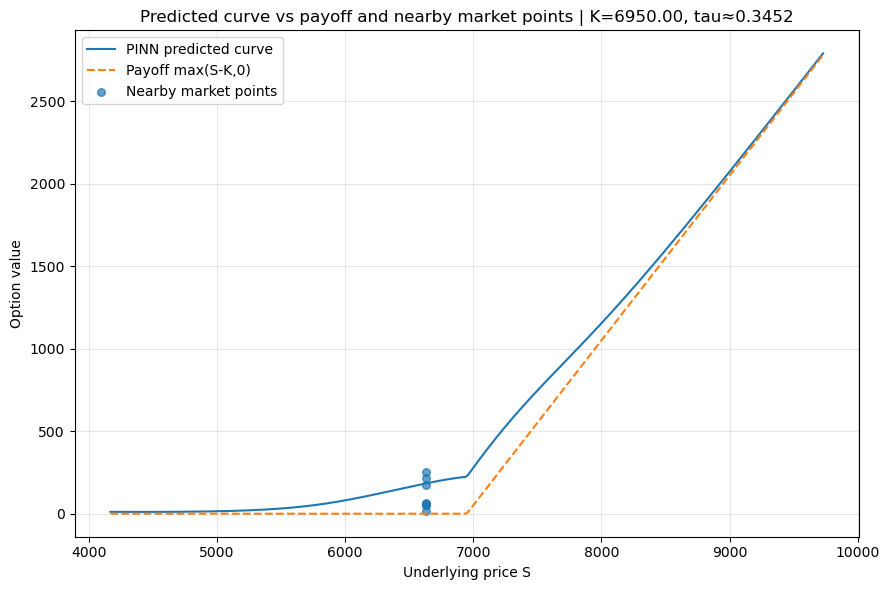

In [138]:
plot_curve_with_market_points(
    model=model,
    df=val_df,
    device=device,
    K=float(val_df["K"].median()),
    tau_target=float(val_df["tau"].median()),
    sigma_target=float(val_df["sigma"].median()),
    tau_tol=0.02,
    sigma_tol=0.05,
    price_col="V",
)

Scaled price MAE   : 0.002140
Scaled price RMSE  : 0.010417
Option price MAE   : 12.374517
Option price RMSE  : 53.040586


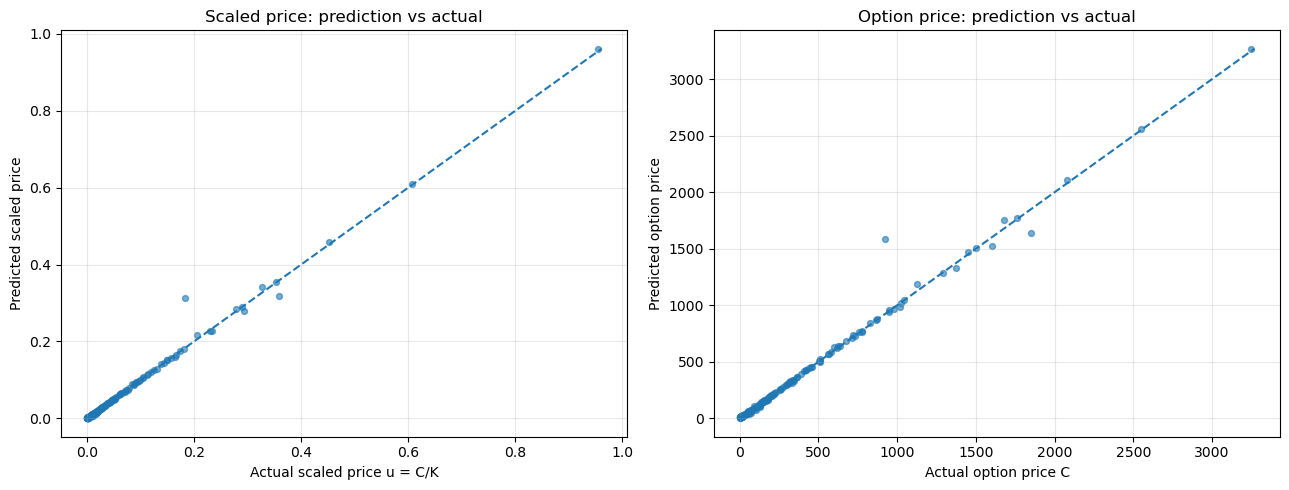

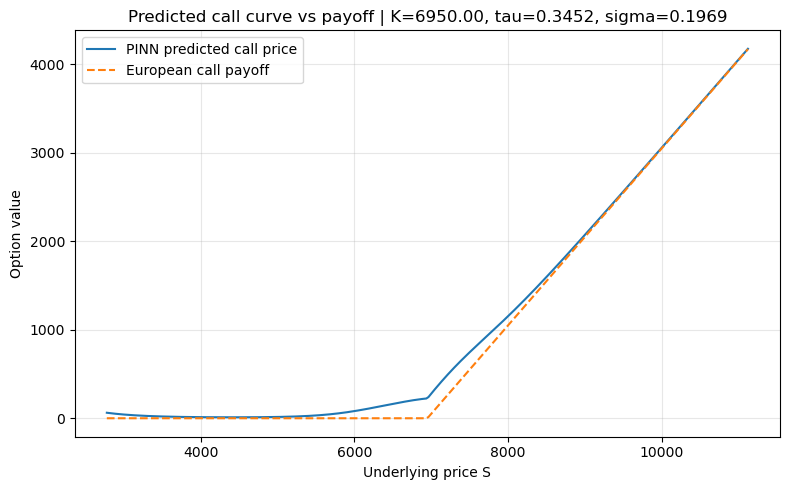

In [139]:
pred_df = make_prediction_df(model, val_df, device=device, price_col="V_scaled")
print_prediction_metrics(pred_df)
plot_prediction_scatter(pred_df)

plot_call_curve_vs_payoff(
    model=model,
    device=device,
    K=float(pred_df["K"].median()),
    tau=float(pred_df["tau"].median()),
    sigma=float(pred_df["sigma"].median()),
)

In [140]:
import torch

def black_scholes_price(S, K, tau, r, sigma, option_type="call"):
    """
    Black-Scholes price for European options, supporting scalars or torch tensors.

    Parameters
    ----------
    S : float or torch.Tensor
        Spot price
    K : float or torch.Tensor
        Strike price
    tau : float or torch.Tensor
        Time to maturity in years
    r : float or torch.Tensor
        Risk-free rate
    sigma : float or torch.Tensor
        Volatility
    option_type : str
        "call" or "put"

    Returns
    -------
    torch.Tensor
        Option price
    """
    S = torch.as_tensor(S)
    K = torch.as_tensor(K, dtype=S.dtype, device=S.device)
    tau = torch.as_tensor(tau, dtype=S.dtype, device=S.device)
    r = torch.as_tensor(r, dtype=S.dtype, device=S.device)
    sigma = torch.as_tensor(sigma, dtype=S.dtype, device=S.device)

    if option_type not in ("call", "put"):
        raise ValueError("option_type must be 'call' or 'put'")

    if torch.any(S <= 0):
        raise ValueError("All S values must be > 0")
    if torch.any(K <= 0):
        raise ValueError("All K values must be > 0")
    if torch.any(tau < 0):
        raise ValueError("All tau values must be >= 0")
    if torch.any(sigma < 0):
        raise ValueError("All sigma values must be >= 0")

    sqrt_tau = torch.sqrt(torch.clamp(tau, min=0))
    normal = torch.distributions.Normal(0.0, 1.0)

    # Safe values for divisions/logs; final output is overwritten where needed
    tau_safe = torch.clamp(tau, min=1e-16)
    sigma_safe = torch.clamp(sigma, min=1e-16)
    vol_sqrt_tau = sigma_safe * torch.sqrt(tau_safe)

    d1 = (torch.log(S / K) + (r + 0.5 * sigma_safe**2) * tau_safe) / vol_sqrt_tau
    d2 = d1 - vol_sqrt_tau

    call_price = S * normal.cdf(d1) - K * torch.exp(-r * tau_safe) * normal.cdf(d2)
    put_price = K * torch.exp(-r * tau_safe) * normal.cdf(-d2) - S * normal.cdf(-d1)

    price = call_price if option_type == "call" else put_price

    # Handle tau == 0
    intrinsic = torch.clamp(S - K, min=0.0) if option_type == "call" else torch.clamp(K - S, min=0.0)
    price = torch.where(tau == 0, intrinsic, price)

    # Handle sigma == 0 and tau > 0
    discounted_strike = K * torch.exp(-r * tau)
    zero_vol_price = (
        torch.clamp(S - discounted_strike, min=0.0)
        if option_type == "call"
        else torch.clamp(discounted_strike - S, min=0.0)
    )
    price = torch.where((sigma == 0) & (tau > 0), zero_vol_price, price)

    return price

In [141]:
import numpy as np
import torch
import matplotlib.pyplot as plt


@torch.no_grad()
def build_surface_comparison(
    model,
    device,
    K,
    sigma,
    r,
    S_min=None,
    S_max=None,
    tau_min=1e-4,
    tau_max=1.0,
    n_S=120,
    n_tau=80,
):
    if S_min is None:
        S_min = 0.5 * K
    if S_max is None:
        S_max = 1.5 * K

    S_grid = np.linspace(S_min, S_max, n_S)
    tau_grid = np.linspace(tau_min, tau_max, n_tau)

    S_mesh, tau_mesh = np.meshgrid(S_grid, tau_grid)
    x_mesh = np.log(S_mesh / K)

    # Flatten for model evaluation
    x_flat = x_mesh.reshape(-1)
    tau_flat = tau_mesh.reshape(-1)
    sigma_flat = np.full_like(x_flat, sigma, dtype=np.float32)
    K_flat = np.full_like(x_flat, K, dtype=np.float32)
    S_flat = S_mesh.reshape(-1).astype(np.float32)

    # PINN prices
    C_pred = predict_price_from_inputs(
        model=model,
        logS_over_K=x_flat,
        tau=tau_flat,
        sigma=sigma_flat,
        K=K_flat,
        device=device,
    ).detach().cpu().numpy().reshape(n_tau, n_S)

    # Black-Scholes prices
    S_t = torch.tensor(S_flat, dtype=torch.float32, device=device).view(-1, 1)
    K_t = torch.tensor(K_flat, dtype=torch.float32, device=device).view(-1, 1)
    tau_t = torch.tensor(tau_flat, dtype=torch.float32, device=device).view(-1, 1)
    sigma_t = torch.tensor(sigma_flat, dtype=torch.float32, device=device).view(-1, 1)

    C_bs = black_scholes_price(
        S=S_t,
        K=K_t,
        tau=tau_t,
        r=r,
        sigma=sigma_t,
    ).detach().cpu().numpy().reshape(n_tau, n_S)

    abs_err = np.abs(C_pred - C_bs)

    return {
        "S_grid": S_grid,
        "tau_grid": tau_grid,
        "C_pred": C_pred,
        "C_bs": C_bs,
        "abs_err": abs_err,
    }

In [142]:
def plot_surface_heatmaps(surface_dict):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]
    abs_err = surface_dict["abs_err"]

    extent = [S_grid.min(), S_grid.max(), tau_grid.min(), tau_grid.max()]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(
        C_pred,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[0].set_title("PINN predicted call price")
    axes[0].set_xlabel("Underlying price S")
    axes[0].set_ylabel("Time to maturity τ")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(
        C_bs,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[1].set_title("Black-Scholes call price")
    axes[1].set_xlabel("Underlying price S")
    axes[1].set_ylabel("Time to maturity τ")
    plt.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(
        abs_err,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    axes[2].set_title("Absolute error |PINN - BS|")
    axes[2].set_xlabel("Underlying price S")
    axes[2].set_ylabel("Time to maturity τ")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

In [143]:
def plot_slices_over_S(surface_dict, taus_to_plot=(0.02, 0.10, 0.25, 0.50, 1.00)):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]

    plt.figure(figsize=(10, 6))

    for tau_target in taus_to_plot:
        idx = np.argmin(np.abs(tau_grid - tau_target))
        tau_used = tau_grid[idx]

        plt.plot(S_grid, C_pred[idx], label=f"PINN τ={tau_used:.3f}")
        plt.plot(S_grid, C_bs[idx], "--", label=f"BS τ={tau_used:.3f}")

    plt.xlabel("Underlying price S")
    plt.ylabel("Option value")
    plt.title("European call price vs underlying for several maturities")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [144]:
def plot_slices_over_tau(surface_dict, S_values_to_plot):
    S_grid = surface_dict["S_grid"]
    tau_grid = surface_dict["tau_grid"]
    C_pred = surface_dict["C_pred"]
    C_bs = surface_dict["C_bs"]

    plt.figure(figsize=(10, 6))

    for S_target in S_values_to_plot:
        idx = np.argmin(np.abs(S_grid - S_target))
        S_used = S_grid[idx]

        plt.plot(tau_grid, C_pred[:, idx], label=f"PINN S={S_used:.0f}")
        plt.plot(tau_grid, C_bs[:, idx], "--", label=f"BS S={S_used:.0f}")

    plt.xlabel("Time to maturity τ")
    plt.ylabel("Option value")
    plt.title("European call price vs maturity for several underlying levels")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2)
    plt.tight_layout()
    plt.show()

In [145]:
def run_bs_surface_demo(
    model,
    device,
    K,
    sigma,
    r,
    S_min=None,
    S_max=None,
    tau_min=1e-4,
    tau_max=1.0,
    n_S=120,
    n_tau=80,
):
    surface = build_surface_comparison(
        model=model,
        device=device,
        K=K,
        sigma=sigma,
        r=r,
        S_min=S_min,
        S_max=S_max,
        tau_min=tau_min,
        tau_max=tau_max,
        n_S=n_S,
        n_tau=n_tau,
    )

    plot_surface_heatmaps(surface)

    plot_slices_over_S(
        surface,
        taus_to_plot=(0.02, 0.10, 0.25, 0.50, 1.00),
    )

    S_vals = [
        0.8 * K,
        0.95 * K,
        1.0 * K,
        1.05 * K,
        1.2 * K,
    ]
    plot_slices_over_tau(surface, S_values_to_plot=S_vals)

    return surface

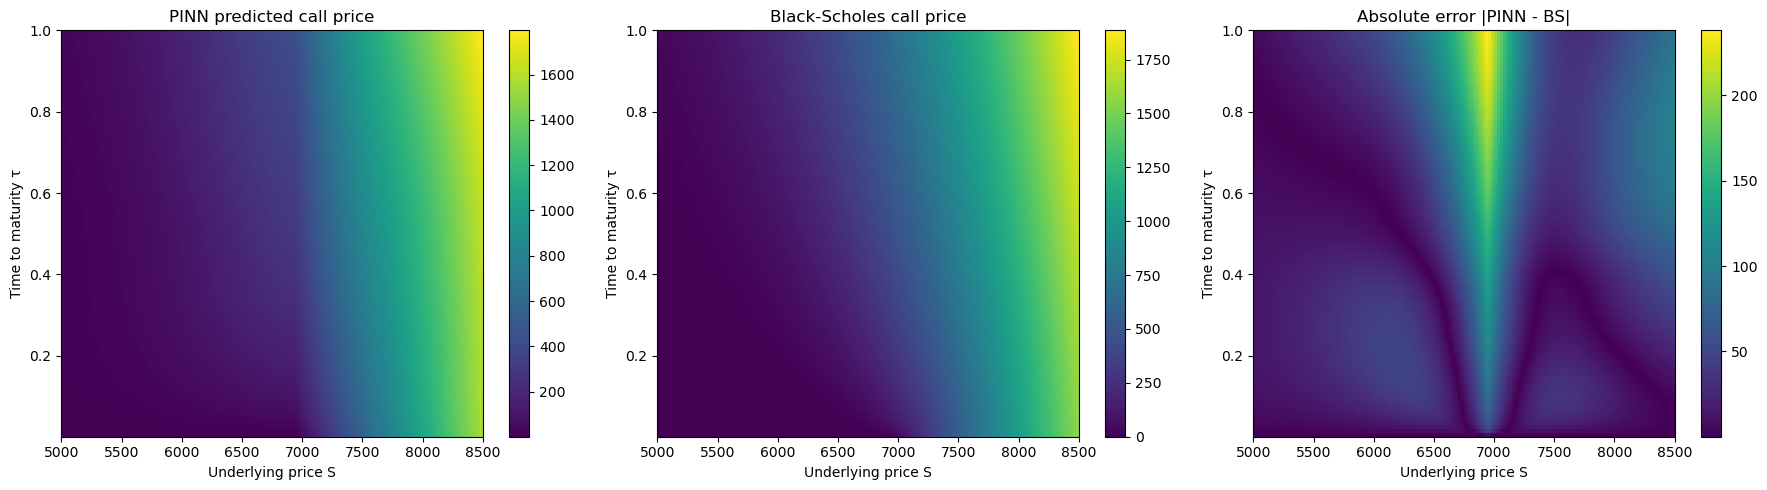

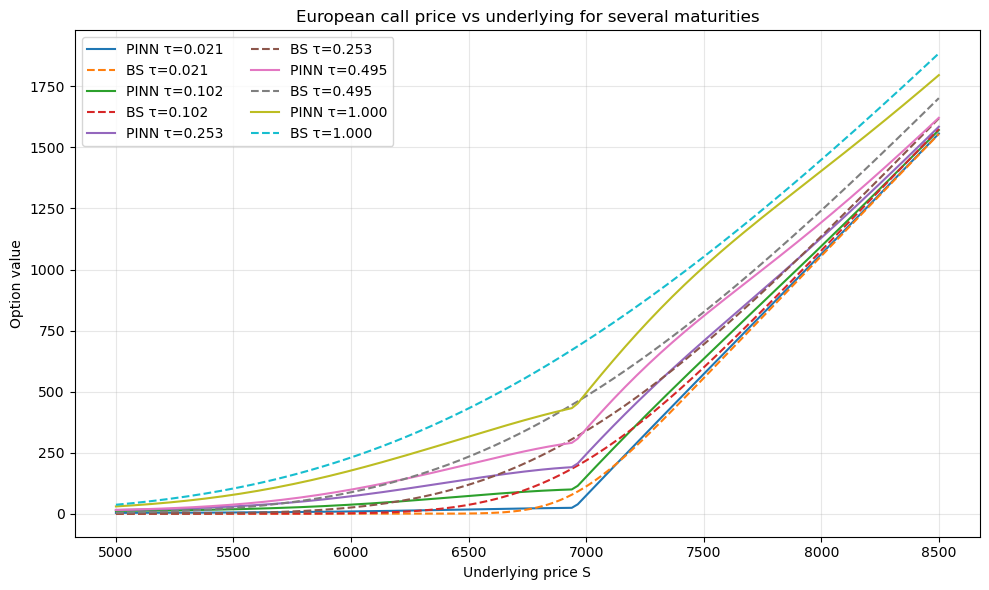

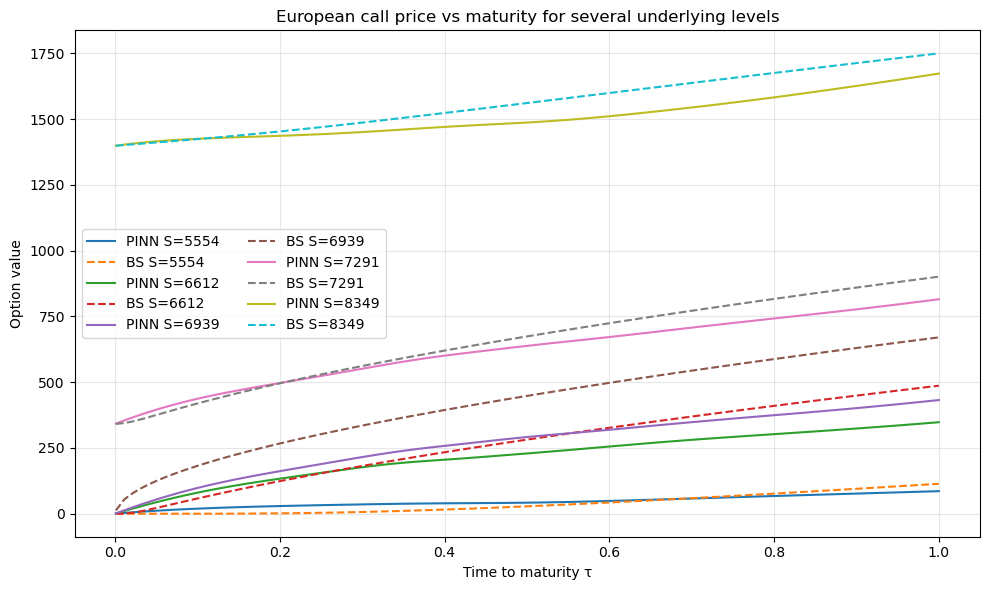

In [146]:
surface = run_bs_surface_demo(
    model=model,
    device=device,
    K=6950.0,
    sigma=0.20,
    r=r,
    S_min=5000,
    S_max=8500,
    tau_min=1e-3,
    tau_max=1.0,
    n_S=140,
    n_tau=100,
)